# Импрорты и нужные классы

In [1]:
import sys
import os
from dotenv import load_dotenv
sys.path.append('..')
env_file = os.path.join('..', '.env')
load_dotenv(env_file)
name_dataset = os.environ['NAME_DATASET']
name_test_dataset = os.environ['NAME_TEST_DATASET']
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_path = os.environ['CASH_PATH']
cache_pdf = os.environ['CASH_PDF_PATH']

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset

In [3]:
loger = Loger('log.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

# Проверка чтения файла

In [4]:
test_file = os.path.join('..', 'test_files', 'PMC5837730_00000.pdf')
# pdf_json = pdf_manager.get_json_from_pdf(test_file, num_page=0)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(test_file, num_page=0)

In [5]:
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

In [6]:
torch_dict = tokenizer(row_json)

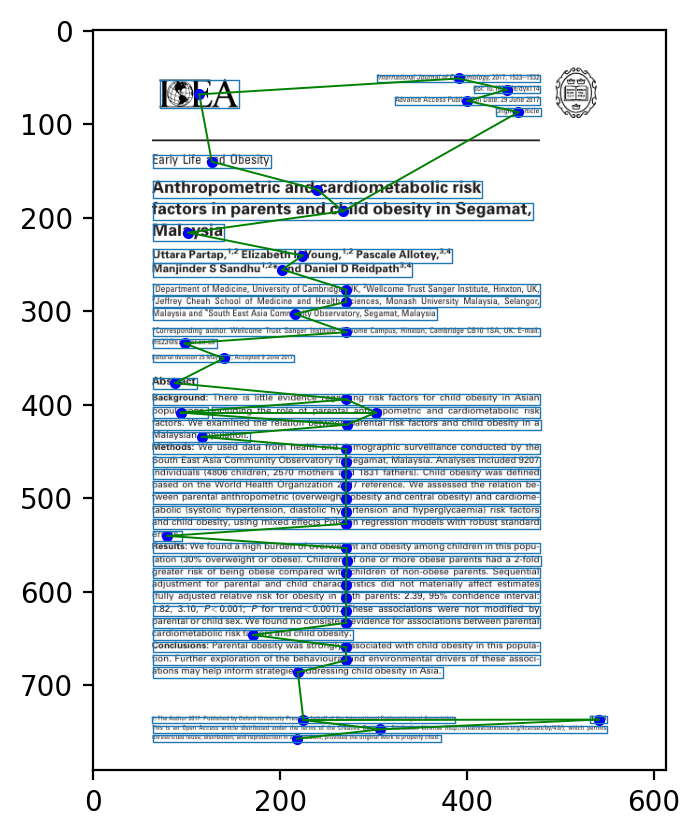

In [7]:
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
# ploter.plot_rows(row_json)
ploter.plot_tokens(tokenizer, torch_dict)

In [8]:
json_true_regions, CLASSES = coco_manager.get_regions_from_json()

In [9]:
CLASSES[3] = "text"
CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [10]:
file_names = list(json_true_regions.keys())
file_names.sort()

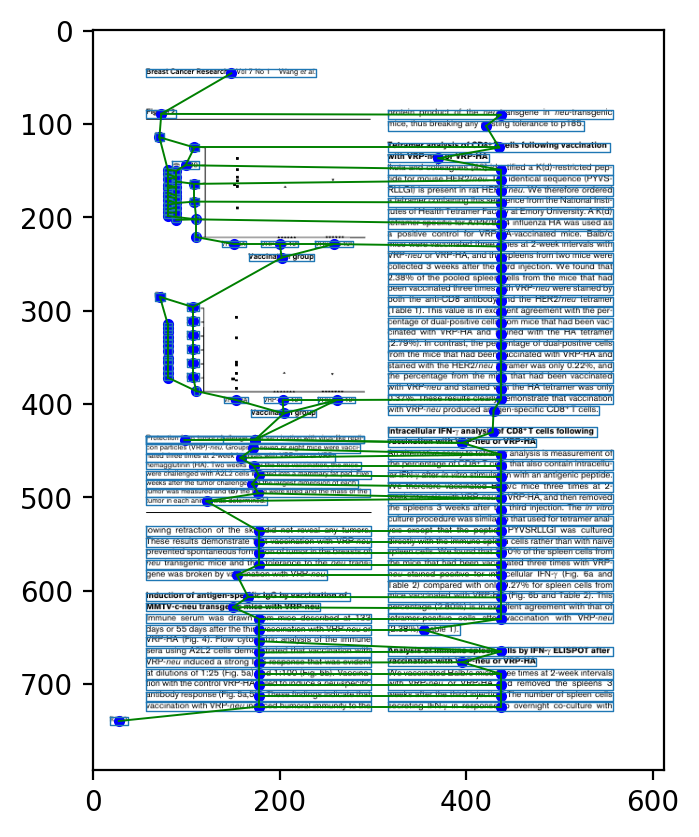

In [11]:
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Конвертер

In [12]:
from pager.page_model.sub_models import BaseConverter, RegionModel, RowsModel
from pager.page_model.sub_models.dtype import ImageSegment, Region, Graph
from pager import MergeExtractor

class Rows2Regions(BaseConverter):
    def __init__(self, conf):
        self.rows2regionsGLAM_tokenizer = conf['tokenizer']# manager_model.get_model("rowGLAM-tokenizer")
        self.rows2regionsGLAM = conf['model']#
        self.is_merge_extract =  conf['is_merge_extract']
        self.merge_extract = MergeExtractor()

        
    def convert(self, input_model: RowsModel, output_model: RegionModel):
        page_json = input_model.to_dict()
        region_list = self.get_region(page_json['rows'])
        output_model.from_dict({"regions": region_list})

        if self.is_merge_extract:
            self.merge_extract.extract(output_model)
        # сортировка после создания региона
        # sorter = RegionSorterCutXYExtractor()
        # sorter.extract(output_model)

    def get_region(self, rows_json):
        graph_dict_torch = self.rows2regionsGLAM_tokenizer(rows_json)
        result = self.rows2regionsGLAM(graph_dict_torch)
        result['deleted_edges'] = result['E_pred'] < 0.5
        
        graph = graph_dict_torch['inds']
        deleted_edges = result['deleted_edges']
        node_classes = result['node_classes']
        regions = self.regions_from_graph(rows_json, graph, deleted_edges, node_classes)
        return regions
    

    def regions_from_graph(self, rows_json, graph, deleted_edges, node_classes):
        graph_ = Graph()
        regions = []
        
        for row_json in rows_json:
            segment = ImageSegment(dict_2p=row_json['segment'])
            xc, yc = segment.get_center()
            graph_.add_node(xc, yc)

        for node_i, node_j, ind in zip(graph[0], graph[1], deleted_edges):
            if not ind:
                graph_.add_edge(node_i+1, node_j+1)

        for reg in graph_.get_related_graphs():
            indexes = [node.index-1 for node in reg.get_nodes()]
            row_classes  = np.array([node_classes[i].detach().numpy() for i in indexes])
            lable = CLASSES[np.argmax(row_classes.mean(axis=0))]
            regions.append({'rows': [rows_json[i] for i in indexes], 'label': lable})
        return regions

# Модель

In [13]:
import torch
from torch.nn import Linear, BCELoss, BCEWithLogitsLoss, CrossEntropyLoss, GELU, HuberLoss,ModuleList
from torch.nn.functional import relu
from torch_geometric.nn import BatchNorm, TAGConv

class TagModule(torch.nn.Module):
    def __init__(self, tag):
        super(TagModule, self).__init__()
        if not "k" in tag.keys():
            tag["k"] = 6
        self.linear =Linear(tag['in'], tag['size'])
        self.tag = TAGConv(tag['size'], tag['out'], K=tag['k'])
        self.activation = GELU()
    
    def forward(self, x, edge_index):
        h = self.linear(x)
        h = self.activation(h)
        h = self.tag(h, edge_index)
        h = self.activation(h)
        return h
    

class NodeGLAM(torch.nn.Module):
    def __init__(self,  params):
        super(NodeGLAM, self).__init__()

        self.activation = GELU()
        self.has_bathcnorm = params['batchNormNode'] if 'batchNormNode' in params.keys() else True
        self.batch_norm1 = BatchNorm(params['node_featch'])

        tags = params['Tag']
        if tags[0]['in'] == -1:
            tags[0]['in'] = params['node_featch']
        linear = params['NodeLinear']
        if linear[0] == -1:
            linear[0] = params['node_featch'] + tags[-1]['out']

        classifier_linear = params['NodeLinearClassifier']
        if classifier_linear[0] == -1:
            classifier_linear[0] = linear[-1]

        
        self.Tag = ModuleList([TagModule(tag) for tag in tags])
        self.Linear = ModuleList([Linear(linear[i], linear[i+1]) for i in range(len(linear)-1)])
        self.classifiers = ModuleList([Linear(classifier_linear[i], classifier_linear[i+1]) for i in range(len(classifier_linear)-1)])
        self.end_classifier = Linear(classifier_linear[-1], params['NodeClasses'])
        
        self.softmax = torch.nn.Softmax()
    
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        if self.has_bathcnorm:
            x = self.batch_norm1(x)
        h = x
        for layer in self.Tag:
            h = layer(h, edge_index)

        a = torch.cat([x, h], dim=1)
        for layer in self.Linear:
            a = self.activation(layer(a))
        
        cl = a
        for clayer in self.classifiers:
            cl = self.activation(clayer(cl))
        cl = self.softmax(self.end_classifier(cl))
        return a, cl

class EdgeGLAM(torch.nn.Module):
    def __init__(self, params):
        super(EdgeGLAM, self).__init__()
        input_  = 2*params["node_featch"]+2*params["NodeLinear"][-1] + params["edge_featch"]
        output_ = 1
        self.activation = GELU()
        self.has_bathcnorm = params['batchNormEdge'] if 'batchNormEdge' in params.keys() else True
        self.has_sigmoid = params['sigmoidEdge'] if 'sigmoidEdge' in params.keys() else False
        self.batch_norm2 = BatchNorm(input_, output_)
        
        linear = params['EdgeLinear']
        if linear[0] == -1:
            linear[0] = input_
        self.Linear = ModuleList([Linear(linear[i], linear[i+1]) for i in range(len(linear)-1)])
        self.linear_end = Linear(linear[-1], output_)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.has_bathcnorm:
            x = self.batch_norm2(x)
        h = x
        for layer in self.Linear:
            h = self.activation(layer(h))
        h = self.linear_end(h)
        if self.has_sigmoid:
            h = torch.sigmoid(h)
        return torch.squeeze(h, 1)

class CustomLoss(torch.nn.Module):
    def __init__(self, params):
        super(CustomLoss, self).__init__()
                    #BCEWithLogitsLoss
        self.bce = BCEWithLogitsLoss(pos_weight=torch.tensor(params['edge_imbalance']))
        self.ce = CrossEntropyLoss(weight=torch.tensor(params['publaynet_imbalance']))
        self.edge_coef:float = params['edge_coef']
        self.node_coef:float = params['node_coef']

    def forward(self, pred_dict, dict_graph):
        # Ребра
        e_pred = pred_dict["E_pred"]
        e_true = dict_graph["true_edges"]
        loss_edge = self.bce(e_pred, e_true)

        # Узлы
        n_pred = pred_dict["node_classes"]
        n_true = dict_graph["true_nodes"]
        loss_node = self.ce(n_pred, n_true) 
        
        # Строковая регуляризация
        # ang = dict_graph['Y'][:, 0]
        # sig_pred = torch.sigmoid(e_pred)
        # ang_loss = torch.dot(1-ang, 1-sig_pred)/ang.shape[0] 

        loss = self.edge_coef*loss_edge  +self.node_coef*loss_node # + 0.5*ang_loss
        return loss

class TorchModel(torch.nn.Module):
    
    def __init__(self, params):
        super(TorchModel, self).__init__()
        self.node_emb = NodeGLAM(params)
        self.bin_edge_emb = EdgeGLAM(params)

    def forward(self, data_graph_dict):
        X: torch.Tensor = data_graph_dict["X"] 
        Y: torch.Tensor = data_graph_dict["Y"]
        sp_A: torch.Tensor = data_graph_dict["sp_A"] 
        inds:List[int] = data_graph_dict["inds"]

        Node_embs, Node_classes = self.node_emb(X, sp_A)
        # Node_embs = self.node_emb(X, sp_A)
        Omega = torch.cat([Node_embs[inds[0]], Node_embs[inds[1]], X[inds[0]], X[inds[1]], Y],dim=1)
        E_pred = self.bin_edge_emb(Omega)
        return {
            "node_classes": Node_classes, 
            "E_pred": E_pred
        }

E:\Work\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Сохранение датасета

In [14]:
from pager.page_model.sub_models.dtype import ImageSegment


def get_true_edges(token, rows, region_segs, region_categories):
    def is_one_region(row_seg_1, row_seg_2, region_segs):
        for i, reg in enumerate(region_segs):
            if reg.is_intersection(row_seg_1):
                if reg.is_intersection(row_seg_2):
                    return 1
                else:
                    return 0
        return 0

    def get_category(seg, region_segs, region_categories):
        for r, c in zip(region_segs, region_categories):
            if seg.is_intersection(r):
                return c
        return None

    def get_mini_seg(r):
        img_seg = ImageSegment(dict_2p=r)
        if img_seg.height < 5:
            return img_seg
        delta =  int(img_seg.height/5)
        img_seg.y_bottom_right = img_seg.y_bottom_right - delta
        img_seg.y_top_left = img_seg.y_top_left + delta
        return img_seg
    row_segments = [get_mini_seg(row['segment']) for row in rows]
    A = token['inds']
    true_edges = [is_one_region(row_segments[i], row_segments[j], region_segs) for i, j in zip(A[0], A[1])]
    true_nodes = [get_category(row_seg, region_segs, region_categories) for row_seg in row_segments]
    return true_edges, true_nodes

def pdf2torch_dict(path_pdf, coco_dict_file):
        try:
            pdf_json = pdf_manager.get_json_from_pdf(path_pdf, num_page=0)
            w, h = pdf_json['width'],pdf_json['height']
            row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
        except:
            print(path_pdf, '\n')
            return {}
        torch_dict = tokenizer(row_json)
        if name_dataset == "doclaynet":
            coef_w, coef_h = w/1024, h/1024
        elif name_dataset == "publaynet":
            coef_w, coef_h = 1, 1
        coco_dict_file['regions'] = [r for r in coco_dict_file['regions'] if r['segment']['height'] > 0]
        reg_segments = [ImageSegment(dict_p_size={
            "x_top_left": int(r['segment']['x_top_left']*coef_w),
            "y_top_left": int(r['segment']['y_top_left']*coef_h),
            "width": int(r['segment']['width']*coef_w),
            "height": int(r['segment']['height']*coef_h)}) for r in coco_dict_file['regions']]
        reg_categories = [r['category_id'] for r in coco_dict_file['regions']]
        true_edges, true_nodes = get_true_edges(torch_dict, row_json, reg_segments, reg_categories)
        
        del torch_dict['sp_A']
        torch_dict['true_edges'] = true_edges
        torch_dict['true_nodes'] = true_nodes

        return torch_dict
         
        print(f"{(i+1)/N*100:4.2f} %", end='\r')

dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": len(CLASSES),
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

# Отрисовска файла из датасета

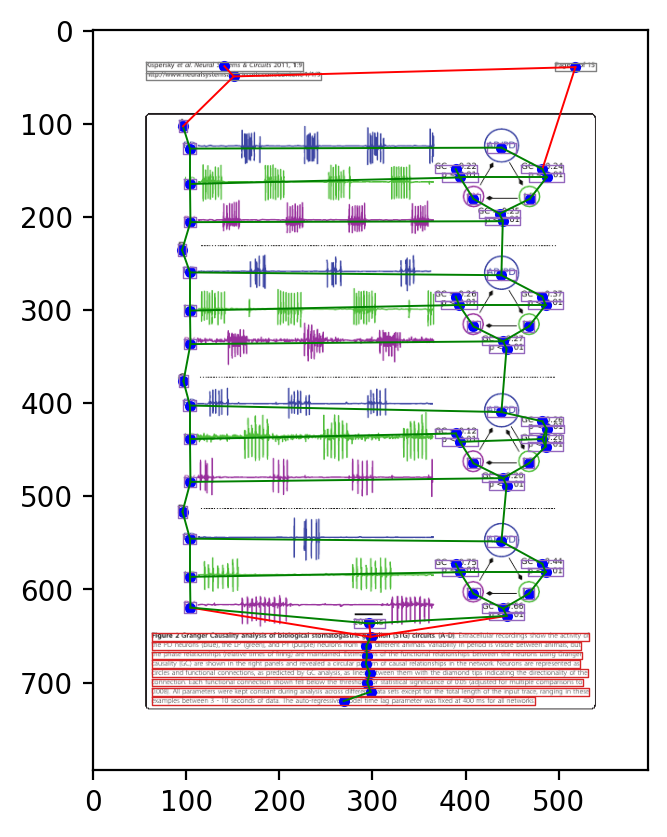

In [15]:
torch_dict2 = dataset[1050]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Регионы --------------------------------------------------------------
# ann = coco_manager.get_regions_from_json()
# regions = ann[torch_dict2['file_name'] + ".pdf"]['regions']

# for reg in regions:
#     seg = ImageSegment(dict_p_size=reg['segment'])
#     seg.plot()

# Параметры модели

In [16]:
GLAM_MODEL = 'row2region_GLAM_artic'
PARAMS  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 128,
    "learning_rate": 0.001,
    "Tag":[  {'in': -1, 'size': 512, 'out': 512, 'k': 3},
            {'in': 512, 'size': 256, 'out': 256, 'k': 3},
            # {'in': 256, 'size': 128, 'out': 128, 'k': 3},
            # {'in': 64, 'size': 32, 'out': 16, 'k': 3},
            ],
    "NodeLinear": [-1, 64, 32],
    "NodeLinearClassifier": [-1, 16, 8],
    "EdgeLinear": [-1, 16, 4],
    "batchNormNode": True,
    "batchNormEdge": True,
    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": len(CLASSES)
}

In [17]:
# Дисбаланс классов ------------------------------------
import numpy as np
positiv = []
negativ = []

positiv_nodes = []
negativ_nodes = []
k = 0
for g in dataset:
    if not "true_edges" in g or not "true_nodes" in g:
        continue 
    M = len(g['true_edges'])
    p = sum(g['true_edges'])
    n = M - p
    positiv.append(p)
    negativ.append(n)

    M = len(g['true_nodes'])
    nodes = np.array(g['true_nodes'])
    pp = nodes.sum(axis=0)
    if type(pp) is np.float32:
        continue
    nn = M - pp
    
    positiv_nodes.append(pp)
    negativ_nodes.append(nn)
    

P = np.mean(positiv)
N = np.mean(negativ)
PP = np.mean(positiv_nodes, axis=0)
NN = np.mean(negativ_nodes, axis=0)
disb_nodes = NN/PP
disb_nodes[PP == 0.0] = 0
# disb_nodes = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
print(PP)
PARAMS['loss_params']['publaynet_imbalance'] = (disb_nodes/sum(disb_nodes)).tolist()
disb = N/P
print(disb)
PARAMS['loss_params']['edge_imbalance'] = float(disb)
PARAMS

[10.976582  62.370296   2.2816253  3.1359088 38.369297   4.816153 ]
0.38259286


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 30,
 'batch_size': 128,
 'learning_rate': 0.001,
 'Tag': [{'in': -1, 'size': 512, 'out': 512, 'k': 3},
  {'in': 512, 'size': 256, 'out': 256, 'k': 3}],
 'NodeLinear': [-1, 64, 32],
 'NodeLinearClassifier': [-1, 16, 8],
 'EdgeLinear': [-1, 16, 4],
 'batchNormNode': True,
 'batchNormEdge': True,
 'seg_k': 0.5,
 'loss_params': {'edge_coef': 0.8,
  'node_coef': 0.2,
  'publaynet_imbalance': [0.07904524356126785,
   0.0074686817824840546,
   0.4100709557533264,
   0.29622960090637207,
   0.017031226307153702,
   0.1901542693376541],
  'edge_imbalance': 0.3825928568840027},
 'sigmoidEdge': False,
 'NodeClasses': 6}

# Обучение модели

In [23]:
model:torch.nn.Module = TorchModel(PARAMS)
total_params = sum(p.numel() for p in model.parameters())  
print(f"Number of parameters: {total_params}") 

Number of parameters: 1473097


In [24]:
import time

def validation(model, batch, criterion):     
    return step(model, batch, optimizer=None, criterion=criterion, train=False)

def split_index_train_val(dataset, val_split=0.2, shuffle=True, seed=1234,batch_size=64):
    N = len(dataset)
    count_batchs = int(N*(1-val_split))//batch_size
    count_val_batch = int(N*(val_split))//batch_size
    train_size = count_batchs * batch_size 
    indexs = [i for i in range(N)]
    if shuffle:
        np.random.shuffle(indexs)
    train_indexs = indexs[:train_size]
    val_indexs = indexs[train_size:]
    batchs_train_indexs = [[train_indexs[k*batch_size+i] for i in range(batch_size)] for k in range(count_batchs)]
    batchs_val_indexs = [[val_indexs[k*batch_size+i] for i in range(batch_size)] for k in range(count_val_batch)]
    return batchs_train_indexs, batchs_val_indexs    

def step(model: torch.nn.Module, batch, optimizer, criterion, train=True):
    if train:
        optimizer.zero_grad()
    my_loss_list = []
   
    for j, data_graph_dict in enumerate(batch):
        try:
            if data_graph_dict is None:
                continue
            pred_graph_dict = model(data_graph_dict)
            loss = criterion(pred_graph_dict, data_graph_dict)
            my_loss_list.append(loss.item())
            print(f"{(j+1)/len(batch)*100:.2f} % Batch loss={my_loss_list[-1]:.4f}" + " "*40, end="\r")
        except Exception as e:
            print(e)
            if "Y" in data_graph_dict.keys():
                print(np.array(data_graph_dict['Y']).shape)
            if "X" in data_graph_dict.keys():
                print(np.array(data_graph_dict['X']).shape)
            continue
        if train:  
            loss.backward()
    if train:
        optimizer.step()
    return np.mean(my_loss_list)

def train_model(params, model, dataset, save_frequency=5, start_epoch=0):  
    optimizer = torch.optim.Adam(
    list(model.parameters()),
    lr=params["learning_rate"],
    )
    criterion = CustomLoss(params["loss_params"]) 

    model.to(device)
    criterion.to(device)

    loss_list = []
    start = time.time()
    train_dataset, val_dataset = split_index_train_val(dataset, val_split=0.1, batch_size=params["batch_size"])
    for k in range(start_epoch, params["epochs"]):
        my_loss_list = []
        if k == start_epoch:
            start = time.time()
        for l, batch_indexs in enumerate(train_dataset):
            batch = [dataset[ind] for ind in batch_indexs]
            batch_loss = step(model, batch, optimizer, criterion)
            my_loss_list.append(batch_loss)
            print(f"Batch # {l+1} loss={my_loss_list[-1]:.4f}" + " "*40, end='\r')
            if (k == start_epoch and l==0):
                print(f"Время обучения batch'а {time.time()-start:.2f} сек")
        train_val = np.mean(my_loss_list)
        loss_list.append(train_val)

        my_loss_list = []
        for l, batch_indexs in enumerate(val_dataset):
            batch = [dataset[ind] for ind in batch_indexs]
            batch_loss = validation(model, batch, criterion)
            my_loss_list.append(batch_loss)
            print(f"Batch # {l+1} loss={my_loss_list[-1]:.4f}" + " "*40, end='\r')
        validation_val =  np.mean(my_loss_list)
        print("="*10, f"EPOCH #{k+1}","="*10, f"({train_val:.4f}/{validation_val:.4f})")
        if k == start_epoch:
            print(f"Время обучения epoch {time.time()-start:.2f} сек")    
            
        loger(f"EPOCH #{k}\t {train_val:.8f} (VAL: {validation_val:.8f})")  
        if (k+1) % save_frequency == 0:
            num = k//save_frequency
            torch.save(model.state_dict(), GLAM_MODEL+f"_tmp_{num}")
    loger(f"Время обучения: {time.time()-start:.2f} сек")
    torch.save(model.state_dict(), GLAM_MODEL)


def load_checkpoint(model, path_model,restart_num=None):
    dir_model = os.path.dirname(path_model)
    name_model = os.path.basename(path_model)
    names = [n for n in os.listdir(dir_model) if name_model+'_tmp_' in n]
    if restart_num is None:
        list_num = [int(n.split("_tmp_")[-1]) for n in names]
        if len(list_num) == 0:
            return
        restart_num = max(list_num) 

    checkpoint_path = os.path.join(dir_model, name_model+f"_tmp_{restart_num}")
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    print(checkpoint_path)
    return restart_num

In [25]:
SAVE_FREQUENCY = 5
device = 'cpu'
if __name__ == "__main__":
    is_restart = False
    restart_num = None
    if is_restart:
        loger("R E S T A R T ")
    loger.time_log()
    try:
        str_ = dataset.__str__()
        str_ += '\n'.join(f"{key}:\t{val}" for key, val in PARAMS.items())
        print(str_)
        if not is_restart:
            loger(str_)
    except:
        print(dataset)
    PARAMS['sigmoidEdge'] = False
    model:torch.nn.Module = TorchModel(PARAMS)
    if is_restart:
        restart_num = load_checkpoint(model, GLAM_MODEL)
    
    start_epoch = 0 if restart_num is None else (restart_num+1)*SAVE_FREQUENCY
    train_model(PARAMS, model, dataset, save_frequency=SAVE_FREQUENCY, start_epoch=start_epoch)

DATASET INFO:
count row: 10000
first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
	 A:torch.Size([104, 104])
	 nodes_feature:torch.Size([104, 15])
	 edges_feature:torch.Size([151, 4])
	 true_edges:torch.Size([151])
end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
	 A:torch.Size([107, 107])
	 nodes_feature:torch.Size([107, 15])
	 edges_feature:torch.Size([108, 4])
	 true_edges:torch.Size([108])

node_featch:	15
edge_featch:	4
epochs:	30
batch_size:	128
learning_rate:	0.001
Tag:	[{'in': 15, 'size': 512, 'out': 512, 'k': 3}, {'in': 512, 'size': 256, 'out': 256, 'k': 3}]
NodeLinear:	[271, 64, 32]
NodeLinearClassifier:	[32, 16, 8]
EdgeLinear:	[98, 16, 4]
batchNormNode:	True
batchNormEdge:	True
seg_k:	0.5
loss_params:	{'edge_coef': 0.8, 'node_coef': 0.2, 'publaynet_imbalance': [0.07904524356126785, 0.0074686817824840546, 0.4100709557533264, 0.29622960090637207, 0.017031226307153702, 0.1901542693376541], 'edge_imba

# Проверка работы модели

In [18]:
PARAMS['sigmoidEdge'] = True
model = TorchModel(PARAMS)
model.load_state_dict(torch.load(GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions = Rows2Regions({
    'model':model, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True
})

E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:66: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  warnings.warn(f"Converting sparse tensor to CSR format for more "
E:\Work\env\Lib\site-packages\torch_geometric\utils\_spmm.py:70: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  src = src.to_sparse_csr()
E:\Work\env\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


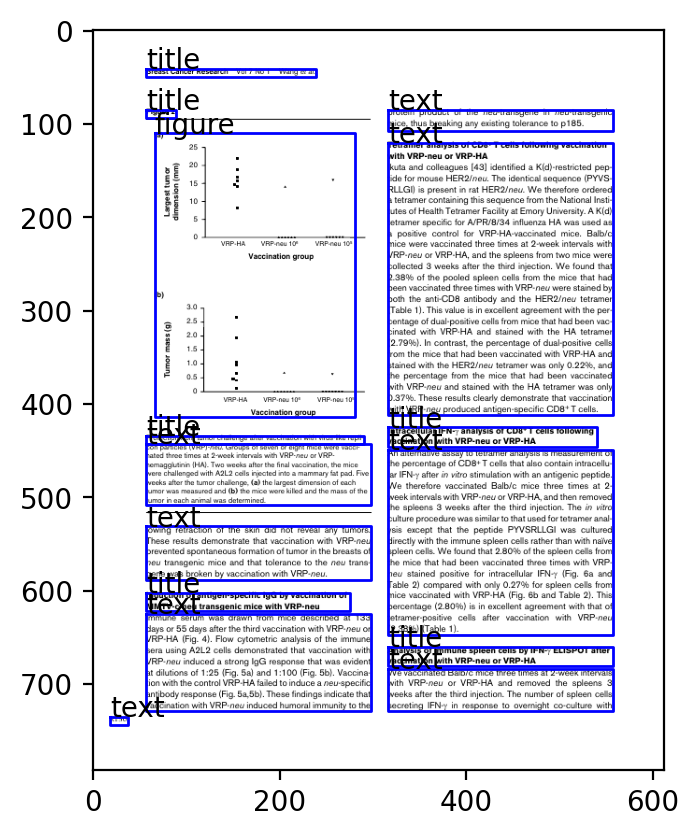

In [19]:
torch_dict2 = dataset[1]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [20]:
from rows2regionsGLAM.metrics import GridMetric
from torchmetrics.detection.mean_ap import MeanAveragePrecision

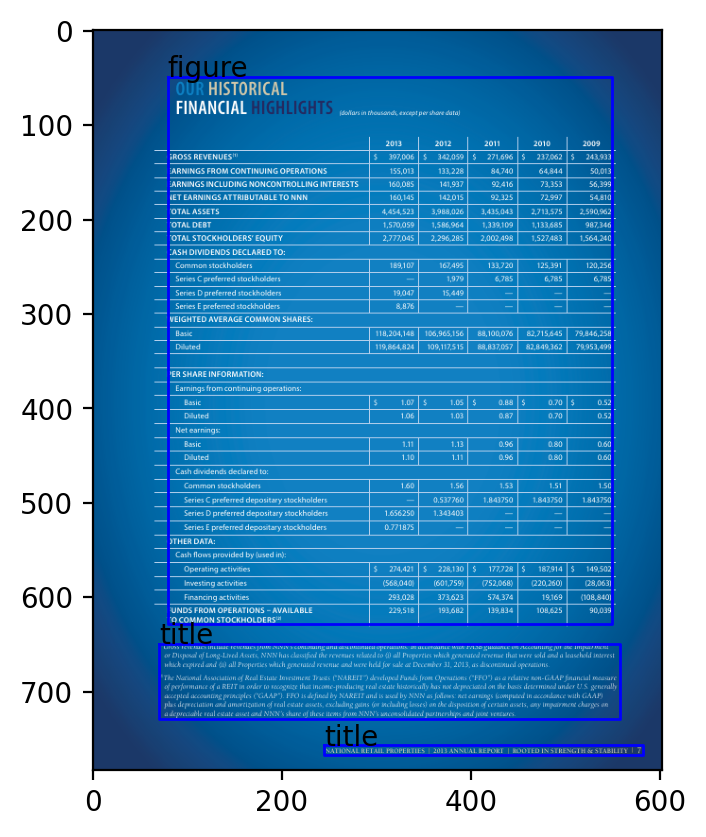

In [22]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = test_dataset[1]
path_pdf = os.path.join(test_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [30]:
COUNT_TEST_SIZE = 200
loger("Start Test")
loger.time_log()

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

100.00 %

## Для проверки переносимости обучения на Doclaynet -> тестирования на Publaynet

In [29]:
DOC2PUB_MAP = {
    'Text': 'text',
    'Title': 'header',
    'Section-header': 'header',
    'List-item': 'list',
    'Table': 'table',
    'Picture': 'figure',
    'Page-header': 'other',
    'Page-footer': 'other',
    'Caption': 'other',
    'Footnote': 'other',
    'Formula': 'other',
    'other': 'other'
}
# Функция для объединения list-item-ов в list-ы
# def aggregate_list_items(regions):
#     list_items = [r for r in regions if r['label'] == 'list']
#     others = [r for r in regions if r['label'] != 'list']

#     if not list_items:
#         return regions

#     list_items = sorted(list_items, key=lambda r: r['segment']['y_top_left'])

#     def x_overlap(a, b, thr=0.3):
#         xa1, xa2 = a['segment']['x_top_left'], a['segment']['x_bottom_right']
#         xb1, xb2 = b['segment']['x_top_left'], b['segment']['x_bottom_right']
#         inter = max(0, min(xa2, xb2) - max(xa1, xb1))
#         min_w = min(xa2 - xa1, xb2 - xb1)
#         return min_w > 0 and inter / min_w >= thr

#     def has_block_between(a, b):
#         y1 = a['segment']['y_bottom_right']
#         y2 = b['segment']['y_top_left']
#         for r in others:
#             ry1 = r['segment']['y_top_left']
#             ry2 = r['segment']['y_bottom_right']
#             if ry1 >= y1 and ry2 <= y2:
#                 return True
#         return False

#     groups = []
#     current = [list_items[0]]

#     for prev, curr in zip(list_items, list_items[1:]):
#         if x_overlap(prev, curr) and not has_block_between(prev, curr):
#             current.append(curr)
#         else:
#             groups.append(current)
#             current = [curr]
#     groups.append(current)

#     merged = []
#     for g in groups:
#         xs1 = [r['segment']['x_top_left'] for r in g]
#         ys1 = [r['segment']['y_top_left'] for r in g]
#         xs2 = [r['segment']['x_bottom_right'] for r in g]
#         ys2 = [r['segment']['y_bottom_right'] for r in g]

#         merged.append({
#             'label': 'list',
#             'segment': {
#                 'x_top_left': min(xs1),
#                 'y_top_left': min(ys1),
#                 'x_bottom_right': max(xs2),
#                 'y_bottom_right': max(ys2)
#             }
#         })

#     return others + merged


## Оценка

In [25]:
import numpy as np
from pager import ImageSegment

def get_bbox(segment, resize = None, delta_w = 0, delta_h = 0):
    coef_w, coef_h = 1, 1
    if resize:
        coef_w, coef_h = resize
    if not "height" in segment:
        segment['width'] = segment['x_bottom_right']-segment['x_top_left']
        segment['height']= segment['y_bottom_right']-segment['y_top_left']
    return [
        int(coef_w*segment['x_top_left']-delta_w),
        int(coef_h*segment['y_top_left']-delta_h),
        int(coef_w*segment['width']+delta_w),
        int(coef_h*segment['height']+delta_h)
    ]

def clean_rows(rows, bboxes_true):
    def is_row_in_region(row, segs_regions):
        for r in segs_regions:
            if row.is_intersection(r):
                return True
        return False
    def is_good_block(block):
        h = block['segment']['y_bottom_right']-block['segment']['y_top_left']
        w = block['segment']['x_bottom_right']-block['segment']['x_top_left']
        return h > 3 and w > 3
        
    old_rows = [row for row in rows if is_good_block(row)]
    segs_row = [ImageSegment(dict_2p=row['segment']) for row in old_rows]
    new_rows = []
    seg_bboxes_true = [ImageSegment(dict_p_size=bbox) for bbox in bboxes_true]
    for i, row in enumerate(segs_row):
        if is_row_in_region(row, seg_bboxes_true):
            new_rows.append(old_rows[i])
    rows = new_rows

def clean_bboxes_true(bboxes_true):
    return [bbox_true for bbox_true in bboxes_true if bbox_true['height'] > 3 and bbox_true['width'] > 3]





target = []
preds = []
word_grids = []
row_grids = []
paths = []
N = len(test_dataset)
for i, d in enumerate(test_dataset):
    name_file = test_dataset.pdf_names[i]
    true_regions = test_dataset.coco_ann[name_file]['regions']
    bboxes_true = clean_bboxes_true([reg['segment'] for reg in true_regions])
    
    pdf_json = pdf_manager.get_json_from_pdf(os.path.join(test_path, name_file))
    w, h = pdf_json['width'],pdf_json['height']
    if name_test_dataset == "doclaynet":
        resize = (w/1024, h/1024)
    else:
        resize = (1, 1)
    row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
    clean_rows(row_json, bboxes_true)
    
    rows_model.from_dict({"rows": row_json})
    try:
        rows2regions.convert(rows_model, region_model)
        pred_regions = region_model.to_dict()['regions']
        
        if name_dataset == "doclaynet" and name_test_dataset == "publaynet":
            for r in pred_regions:
                pub_label = DOC2PUB_MAP.get(r['label'], 'other')
                r['label'] = pub_label
            pred_regions = aggregate_list_items(pred_regions)
            
        bboxes_pred = [r['segment'] for r in pred_regions if r['label'] != 'other']
        
        word_grids.append([get_bbox(word['segment']) for row in row_json for word in row['words']])
        row_grids.append([get_bbox(row['segment']) for row in row_json])
        target.append([get_bbox(seg, resize) for seg in bboxes_true])
        preds.append([get_bbox(seg) for seg in bboxes_pred])
    except:
        print(i,d["file_name"])

    
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

27 55bc17a32c171e1efa89be1bb04619cac98ec1fece7986bf119891e4145c257e
34 61dac4cb4814a755d271cbacfb3c051927528f4dd49952d8a7056e1359533f02
36 62b2b9083388997db41c1397430165188d16bdec59b3fdf5175892b3cb7da21c
43 6bfd58c479687cbc2c5834555de0f64dd6bb820bc419f3c9b1a1cd1e67b9f2b0
61 96e7b57ddebc5fb55960335e6771f4d948532830c02dcf445e27a2864333a189
64 9d8f0c83605bd24c3f997f9e54f5c66fd0c9bc6e3e812ec569ce640521ae905c
69 b1f0d398e365070dadc2c560fa7ef90f19435762d37b7e787b75a3c0b11c2bc6
71 b6953846272754e54bbe6465b2a28697ef51c7efc30f13ee9c462f4e2018f67b
74 b9cc278329c412a8d5d7ac22070257ba53981c645dfbac1d859a35028c7ae723
86 d4000809affc277416845340c28c77f50422c4fdaeae41ed28ccc8e7e1d05367
100.00 %

In [26]:
grid_metric = GridMetric()

i = 0
N = len(preds)
for bboxes_pred, bboxes_true, grid_row, grid_word in zip(preds, target, row_grids, word_grids):
    i+=1
    try:
        grid_metric.add_pair(bboxes_pred, bboxes_true, grid_row, grid_word)
        print(f"{(i)/N*100:4.2f} %", end='\r')
    except:
        pass
grid_metric.update()        

100.00 %

In [ ]:
map_metric = MeanAveragePrecision(box_format="xywh")

get_category = lambda an: 1

map_metric.update([dict(     
                    boxes=torch.tensor(bboxes_pred) ,
                    scores=torch.tensor([1.0 for an in bboxes_pred]),
                    labels=torch.tensor([get_category(an) for an in bboxes_pred]),
                    ) for bboxes_pred in preds], 
                  [dict(     
                        boxes=torch.tensor(bboxes_true) ,
                        labels=torch.tensor([get_category(an) for an in bboxes_true]),
                        ) for bboxes_true in target])  
rez = map_metric.compute()
map_metric_rez = f"mAP@IoU[0.50:0.95]   :{rez['map']:.8f}"

In [28]:
print(map_metric_rez)
print(grid_metric)
loger("Test Result")
loger(map_metric_rez)
loger(grid_metric.__str__())

mAP@IoU[0.50:0.95]   :0.24544346
threshold_05--------------------
precision_row       :0.7096
recall_row          :0.4915
f1_row              :0.5807
precision_word      :0.6831
recall_word         :0.4742
f1_word             :0.5598
threshold_95--------------------
precision_row       :0.5043
recall_row          :0.3573
f1_row              :0.4183
precision_word      :0.4780
recall_word         :0.3396
f1_word             :0.3971



In [ ]:
mAP@IoU[0.50:0.95]   :0.52044123
==================================================
threshold_05--------------------
precision_row       :0.8745
recall_row          :0.7442
f1_row              :0.8041
precision_word      :0.8312
recall_word         :0.7130
f1_word             :0.7676
threshold_95--------------------
precision_row       :0.7275
recall_row          :0.6222
f1_row              :0.6707
precision_word      :0.6884
recall_word         :0.5949
f1_word             :0.6382